# Stephen Curry 2023 Shot Probability Notebook

This notebook computes overall, binomial, conditional, and Bayes probabilities from `stephen_curry_shots_2023.csv` using a single-pass counting approach for speed and low memory use.

In [9]:
import csv
from collections import Counter
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt

csv_path = Path('stephen_curry_shots_2023.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Cannot find dataset: {csv_path}')

# One pass over the file: fast, reliable, and memory-conscious.
counts = Counter()
n = 0

with csv_path.open(newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    required = {'result', 'shot_type', 'lead'}
    if not required.issubset(set(reader.fieldnames or [])):
        raise KeyError(f'Missing required columns. Found: {reader.fieldnames}')

    for row in reader:
        n += 1
        result = row['result'].strip()
        shot_type = row['shot_type'].strip()
        lead = row['lead'].strip()

        counts['make'] += int(result == 'True')
        counts['miss'] += int(result == 'False')
        counts['three'] += int(shot_type == '3')
        counts['two'] += int(shot_type == '2')
        counts['lead_true'] += int(lead == 'True')

        # Joint counts used for Bayes theorem.
        counts['make_and_three'] += int(result == 'True' and shot_type == '3')
        counts['make_and_two'] += int(result == 'True' and shot_type == '2')
        counts['lead_and_three'] += int(lead == 'True' and shot_type == '3')
        counts['lead_and_two'] += int(lead == 'True' and shot_type == '2')

if n == 0:
    raise ValueError('Dataset is empty.')

def p(k):
    return counts[k] / n

print(f'Total shots: {n}')
print(f'Makes: {counts["make"]}, Misses: {counts["miss"]}')
print(f'Three-pointers: {counts["three"]}, Two-pointers: {counts["two"]}')

Total shots: 1434
Makes: 703, Misses: 731
Three-pointers: 786, Two-pointers: 648


## Overall Shooting Statistics
We report the baseline probabilities directly from the dataset counts.

In [10]:
p_make = p('make')
p_miss = p('miss')
p_three = p('three')
p_two = p('two')

print('Overall probability of a make, P(Made):', f'{p_make:.6f}')
print('Overall probability of a miss, P(Miss):', f'{p_miss:.6f}')
print('Overall proportion of three-pointers, P(3):', f'{p_three:.6f}')
print('Overall proportion of two-pointers, P(2):', f'{p_two:.6f}')

print('\nCheck: P(Made)+P(Miss)=', f'{p_make + p_miss:.6f}')
print('Check: P(3)+P(2)=', f'{p_three + p_two:.6f}')

Overall probability of a make, P(Made): 0.490237
Overall probability of a miss, P(Miss): 0.509763
Overall proportion of three-pointers, P(3): 0.548117
Overall proportion of two-pointers, P(2): 0.451883

Check: P(Made)+P(Miss)= 1.000000
Check: P(3)+P(2)= 1.000000


### Overall Shooting Visualization
This first slide summarizes the baseline make/miss and shot-type probabilities.

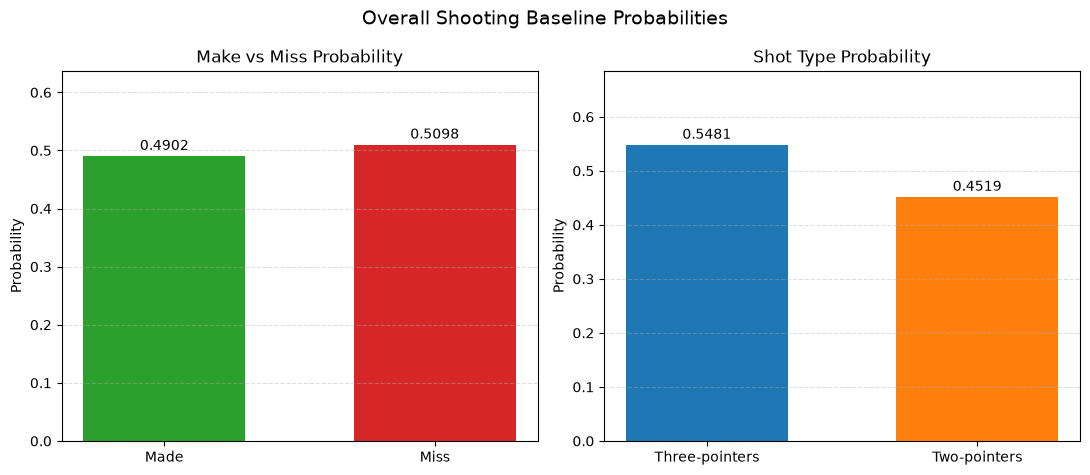

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

overall_labels_1 = ['Made', 'Miss']
overall_values_1 = [p_make, p_miss]
bars1 = axes[0].bar(overall_labels_1, overall_values_1, color=['#2ca02c', '#d62728'], width=0.6)
axes[0].set_title('Make vs Miss Probability')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, max(overall_values_1) * 1.25)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for bar, value in zip(bars1, overall_values_1):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.005, f'{value:.4f}', ha='center', va='bottom')

overall_labels_2 = ['Three-pointers', 'Two-pointers']
overall_values_2 = [p_three, p_two]
bars2 = axes[1].bar(overall_labels_2, overall_values_2, color=['#1f77b4', '#ff7f0e'], width=0.6)
axes[1].set_title('Shot Type Probability')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, max(overall_values_2) * 1.25)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for bar, value in zip(bars2, overall_values_2):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.005, f'{value:.4f}', ha='center', va='bottom')

fig.suptitle('Overall Shooting Baseline Probabilities', fontsize=14)
plt.tight_layout()
plt.show()

> [!IMPORTANT]
> **Slide takeaway**
> Steph's 2023 shot profile is nearly balanced between makes and misses, and he takes more three-pointers than two-pointers overall.

## Binomial Probabilities
Using $X \sim \text{Binomial}(n, p)$ and the formula $P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}$.

In [12]:
# 1) Probability Steph makes exactly 3 of next 4 shots
n1, k1 = 4, 3
prob_3_of_4 = comb(n1, k1) * (p_make ** k1) * ((1 - p_make) ** (n1 - k1))

# 2) Probability exactly 4 of next 5 shots are three-pointers
n2, k2 = 5, 4
prob_4_of_5_three = comb(n2, k2) * (p_three ** k2) * ((1 - p_three) ** (n2 - k2))

print('P(3 makes in next 4 shots):')
print(f'  C(4,3) * p_make^3 * (1-p_make)^1 = {prob_3_of_4:.6f}')

print('P(4 three-pointers in next 5 shots):')
print(f'  C(5,4) * p_three^4 * (1-p_three)^1 = {prob_4_of_5_three:.6f}')

P(3 makes in next 4 shots):
  C(4,3) * p_make^3 * (1-p_make)^1 = 0.240241
P(4 three-pointers in next 5 shots):
  C(5,4) * p_three^4 * (1-p_three)^1 = 0.203934


### Probability Visual Summary
This chart compares the two binomial probabilities calculated above.

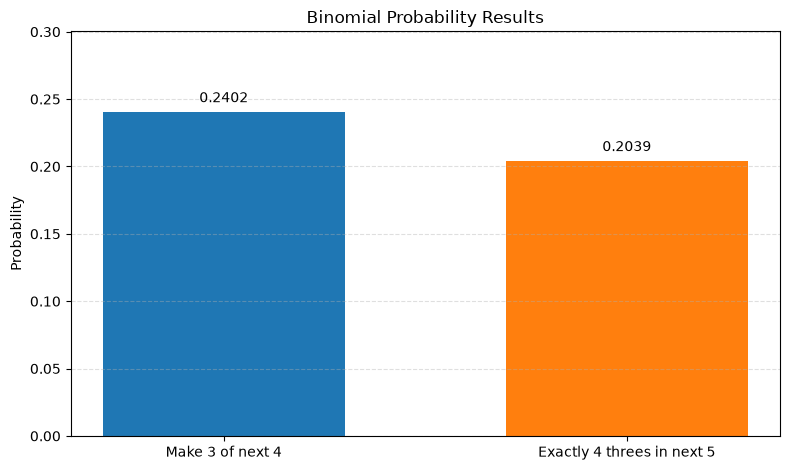

In [13]:
labels = ['Make 3 of next 4', 'Exactly 4 threes in next 5']
values = [prob_3_of_4, prob_4_of_5_three]
colors = ['#1f77b4', '#ff7f0e']

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(labels, values, color=colors, width=0.6)
ax.set_title('Binomial Probability Results')
ax.set_ylabel('Probability')
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.005, f'{value:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

> [!TIP]
> **Slide takeaway**
> The chance of exactly 3 makes in 4 shots is slightly higher than the chance of exactly 4 three-pointers in 5 shots, but both are in the low 20% range.

### Binomial Assumptions
Assumptions used:
1. Fixed number of trials ($n$ is fixed).
2. Two outcomes per trial for each event definition (for makes: make/miss; for shot type: 3/not-3).
3. Constant probability across trials (same $p$ each shot).
4. Independent trials.

Do these hold exactly in basketball? Usually not exactly.
- Probabilities can change by fatigue, defender, game context, and shot selection.
- Shots may be serially dependent (hot/cold streaks, tactical adjustments).

Conclusion: the binomial model is a useful approximation, but assumptions 3 and 4 are likely somewhat violated in real gameplay.

## Conditional Probabilities - Future (Bayes Theorem)
We use Bayes in the equivalent product form:
$$P(A\mid B)=\frac{P(A\cap B)}{P(B)}$$
with terms estimated from dataset frequencies.

In [14]:
# Given next shot is a 3-pointer
p_make_and_three = p('make_and_three')
p_lead_and_three = p('lead_and_three')

p_make_given_three = p_make_and_three / p_three
p_lead_given_three = p_lead_and_three / p_three

# Given next shot is a 2-pointer
p_make_and_two = p('make_and_two')
p_lead_and_two = p('lead_and_two')

p_make_given_two = p_make_and_two / p_two
p_lead_given_two = p_lead_and_two / p_two

print('Given next shot is a THREE-pointer:')
print(f'  P(Made|3) = P(Made and 3)/P(3) = {p_make_and_three:.6f}/{p_three:.6f} = {p_make_given_three:.6f}')
print(f'  P(Lead|3) = P(Lead and 3)/P(3) = {p_lead_and_three:.6f}/{p_three:.6f} = {p_lead_given_three:.6f}')

print('\nGiven next shot is a TWO-pointer:')
print(f'  P(Made|2) = P(Made and 2)/P(2) = {p_make_and_two:.6f}/{p_two:.6f} = {p_make_given_two:.6f}')
print(f'  P(Lead|2) = P(Lead and 2)/P(2) = {p_lead_and_two:.6f}/{p_two:.6f} = {p_lead_given_two:.6f}')

Given next shot is a THREE-pointer:
  P(Made|3) = P(Made and 3)/P(3) = 0.229428/0.548117 = 0.418575
  P(Lead|3) = P(Lead and 3)/P(3) = 0.270572/0.548117 = 0.493639

Given next shot is a TWO-pointer:
  P(Made|2) = P(Made and 2)/P(2) = 0.260809/0.451883 = 0.577160
  P(Lead|2) = P(Lead and 2)/P(2) = 0.232915/0.451883 = 0.515432


### Future Conditional Probability Visual Summary
This grouped bar chart compares make probability and lead probability by shot type.

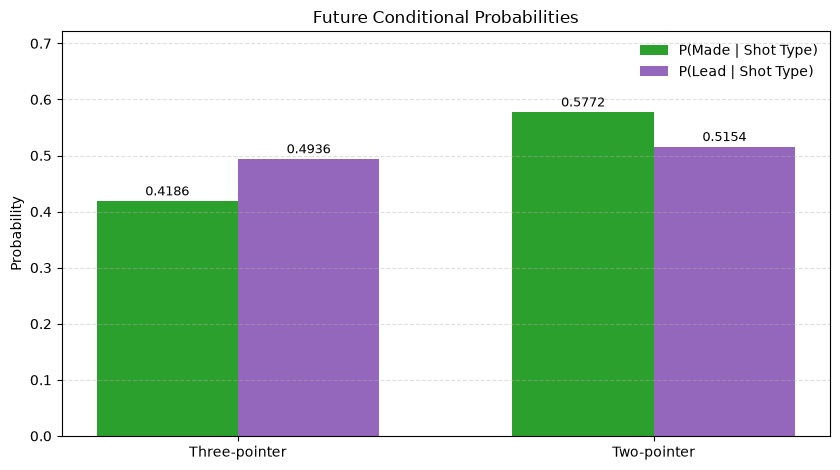

In [15]:
labels = ['Three-pointer', 'Two-pointer']
make_probs = [p_make_given_three, p_make_given_two]
lead_probs = [p_lead_given_three, p_lead_given_two]
x = [0, 1]
width = 0.34

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars1 = ax.bar([i - width / 2 for i in x], make_probs, width, label='P(Made | Shot Type)', color='#2ca02c')
bars2 = ax.bar([i + width / 2 for i in x], lead_probs, width, label='P(Lead | Shot Type)', color='#9467bd')
ax.set_title('Future Conditional Probabilities')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(make_probs + lead_probs) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(frameon=False)
for bars in (bars1, bars2):
    for bar in bars:
        value = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.005, f'{value:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

> [!NOTE]
> **Slide takeaway**
> Steph is more likely to make a two-pointer than a three-pointer, and lead-state probabilities are close to 50% for both shot types.

## Conditional Probabilities - Past (Bayes Theorem, Show Steps)
If Steph just made a shot, we want $P(3\mid Made)$ and $P(2\mid Made)$.

Mapping to notation:
- made three-pointer: $P(Made \cap 3)$
- three-pointer given a make: $P(3\mid Made)$
- make: $P(Made)$

Bayes/frequency form:
$$P(3\mid Made)=\frac{P(Made \cap 3)}{P(Made)}, \quad P(2\mid Made)=\frac{P(Made \cap 2)}{P(Made)}$$

In [16]:
p_three_given_make = p_make_and_three / p_make
p_two_given_make = p_make_and_two / p_make

print('If Steph just made a shot:')
print(f'  P(3|Made) = P(Made and 3)/P(Made) = {p_make_and_three:.6f}/{p_make:.6f} = {p_three_given_make:.6f}')
print(f'  P(2|Made) = P(Made and 2)/P(Made) = {p_make_and_two:.6f}/{p_make:.6f} = {p_two_given_make:.6f}')
print(f'  Check sum: P(3|Made)+P(2|Made) = {p_three_given_make + p_two_given_make:.6f}')

If Steph just made a shot:
  P(3|Made) = P(Made and 3)/P(Made) = 0.229428/0.490237 = 0.467994
  P(2|Made) = P(Made and 2)/P(Made) = 0.260809/0.490237 = 0.532006
  Check sum: P(3|Made)+P(2|Made) = 1.000000


### Past Conditional Probability Visual Summary
This chart visualizes the Bayes results for the shot type given that Steph made the shot.

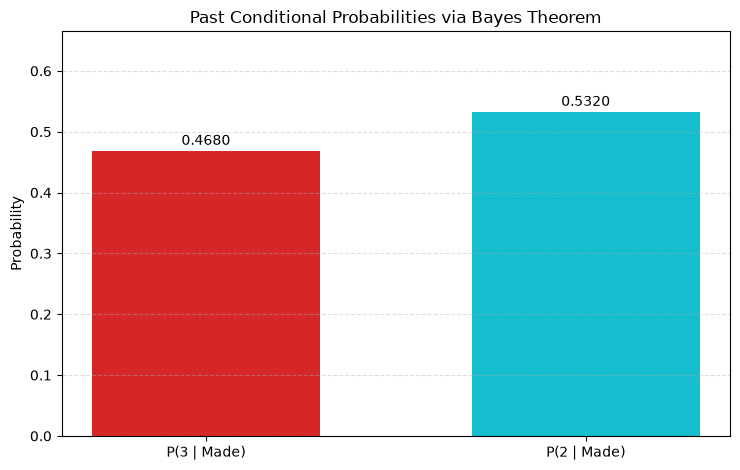

In [17]:
labels = ['P(3 | Made)', 'P(2 | Made)']
values = [p_three_given_make, p_two_given_make]
colors = ['#d62728', '#17becf']

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(labels, values, color=colors, width=0.6)
ax.set_title('Past Conditional Probabilities via Bayes Theorem')
ax.set_ylabel('Probability')
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.005, f'{value:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

> [!IMPORTANT]
> **Slide takeaway**
> Given that Steph made the shot, it is slightly more likely to have been a two-pointer than a three-pointer.

## Final Report Values (Rounded)
- $P(Made)=0.4902$, $P(Miss)=0.5098$
- $P(3)=0.5481$, $P(2)=0.4519$
- $P(3\text{ makes in }4)=0.2402$
- $P(4\text{ threes in }5)=0.2039$
- $P(Made\mid 3)=0.4186$, $P(Lead\mid 3)=0.4936$
- $P(Made\mid 2)=0.5772$, $P(Lead\mid 2)=0.5154$
- $P(3\mid Made)=0.4680$, $P(2\mid Made)=0.5320$

## Executive Summary

> [!IMPORTANT]
> **Three key conclusions**
> 1. Steph's overall make probability is $0.4902$, and his shot profile leans toward three-pointers with $P(3)=0.5481$.
> 2. Under the binomial model, making exactly 3 of the next 4 shots ($0.2402$) is slightly more likely than taking exactly 4 three-pointers in the next 5 shots ($0.2039$).
> 3. The conditional results show better efficiency on two-pointers than three-pointers, and a made shot is slightly more likely to have been a two-pointer than a three-pointer.